# CSC413 - Project Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import nltk
import string
import re
import csv
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from google.colab import files

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Loading the Data

In [ ]:
def convert_txt_to_csv(input_filename, output_filename):
    with open(input_filename, mode='r', newline='', encoding='utf-8') as infile, \
          open(output_filename, mode='w', newline='', encoding='utf-8') as outfile:

        reader = csv.reader(infile, delimiter=';')
        writer = csv.writer(outfile, delimiter=',')
        writer.writerow(['text', 'emotion'])
        for row in reader:
            writer.writerow(row)

traintxt = 'train.txt'
train = 'train.csv'
convert_txt_to_csv(traintxt, train)

testtxt = 'test.txt'
test = 'test.csv'
convert_txt_to_csv(testtxt, test)

valtxt = 'val.txt'
val = 'val.csv'
convert_txt_to_csv(valtxt, val)

### Data Analysis

In [ ]:
def load_data(filename):
  df = pd.read_csv(filename)
  df['text'] = df['text'].str.lower().str.strip()
  df['emotion'] = df['emotion'].str.lower().str.strip()
  df = df.drop_duplicates()
  return df

df = load_data('train.csv')
testdf = load_data('test.csv')
valdf = load_data('val.csv')

df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

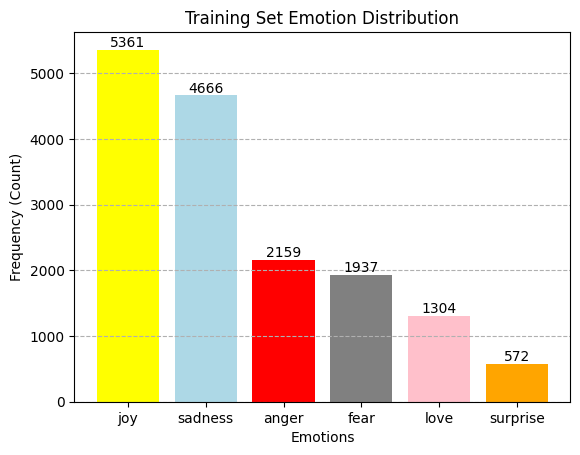

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

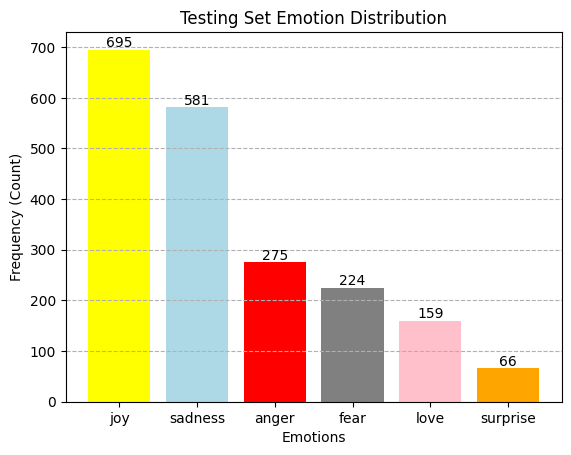

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

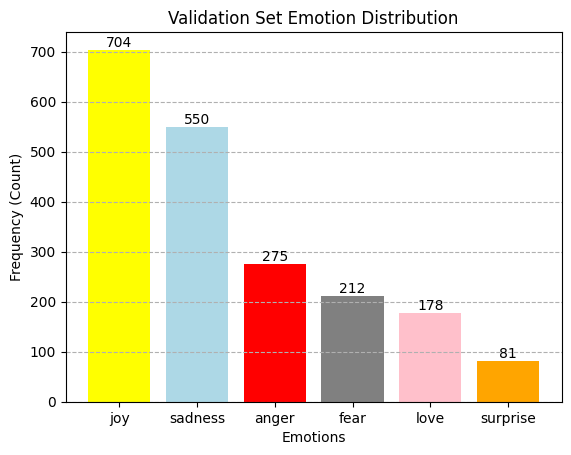

In [ ]:
def emotion_distribution(df, title=''):
    labels = df['emotion'].value_counts().index
    count = df['emotion'].value_counts().values

    bars = plt.bar(labels, count, color=['yellow', 'lightblue', 'red', 'grey', 'pink', 'orange'])
    plt.xlabel('Emotions')
    plt.ylabel('Frequency (Count)')
    plt.title(title + 'Emotion Distribution')
    plt.grid(axis='y', linestyle='--')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, str(height), ha='center', va='bottom')

    plt.savefig(title + 'Emotion Distribution.jpg')
    files.download(title + 'Emotion Distribution.jpg')
    plt.show()

emotion_distribution(df, "Training Set ")
emotion_distribution(testdf, "Testing Set ")
emotion_distribution(valdf, "Validation Set ")

## Data Cleaning and Formatting

In [ ]:
### Remove Punctuation

In [ ]:
def remove_punct(text):
  text  = "".join([c for c in text if c not in string.punctuation])
  text = re.sub('[0-9]+', '', text)
  return text

df['remove_punct'] = df['text'].apply(remove_punct)
df.head()

,text,emotion,remove_punct
0,i didnt feel humiliated,sadness,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,anger,i am feeling grouchy


### Removing Stopwords

In [ ]:
stopword = nltk.corpus.stopwords.words('english')
stopword.extend(
    ['yr', 'year', 'woman', 'man', 'girl','boy','one', 'two', 'sixteen',
     'yearold', 'fu', 'weeks', 'week', 'treatment', 'associated', 'patients',
     'may','day', 'case','old','u','n','didnt','ive','ate','feel','keep',
     'brother','dad','basic','im', 'feeling', 'felt'])
keepword = [
    'not', 'no', 'nor', 'never', 'none', 'without', 'dont', 'didnt', 'doesnt',
    'isnt', 'arent', 'wasnt', 'werent', 'cant', 'couldnt', 'wont', 'wouldnt',
    'shouldnt', 'mustnt', 'havent', 'hasnt', 'hadnt', 'mightnt', 'shant']
stopword = [word for word in stopword if word not in keepword]

def remove_stopwords(text):
    words = text.split()
    words = " ".join([w for w in words if w not in stopword])
    return words

df['remove_stop'] = df['remove_punct'].apply(remove_stopwords)
df.head()

,text,emotion,remove_punct,remove_stop
0,i didnt feel humiliated,sadness,i didnt feel humiliated,didnt humiliated
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...,go hopeless damned hopeful around someone care...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong,grabbing minute post greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...,ever nostalgic fireplace know still property
4,i am feeling grouchy,anger,i am feeling grouchy,grouchy


### Tokenizing Text

In [ ]:
def tokenize(text):
    words = text.split()
    return words

df['tokenized'] = df['remove_stop'].apply(tokenize)
df.head()

,text,emotion,remove_punct,remove_stop,tokenized
0,i didnt feel humiliated,sadness,i didnt feel humiliated,didnt humiliated,"[didnt, humiliated]"
1,i can go from feeling so hopeless to so damned...,sadness,i can go from feeling so hopeless to so damned...,go hopeless damned hopeful around someone care...,"[go, hopeless, damned, hopeful, around, someon..."
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing a minute to post i feel greedy wrong,grabbing minute post greedy wrong,"[grabbing, minute, post, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,love,i am ever feeling nostalgic about the fireplac...,ever nostalgic fireplace know still property,"[ever, nostalgic, fireplace, know, still, prop..."
4,i am feeling grouchy,anger,i am feeling grouchy,grouchy,[grouchy]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

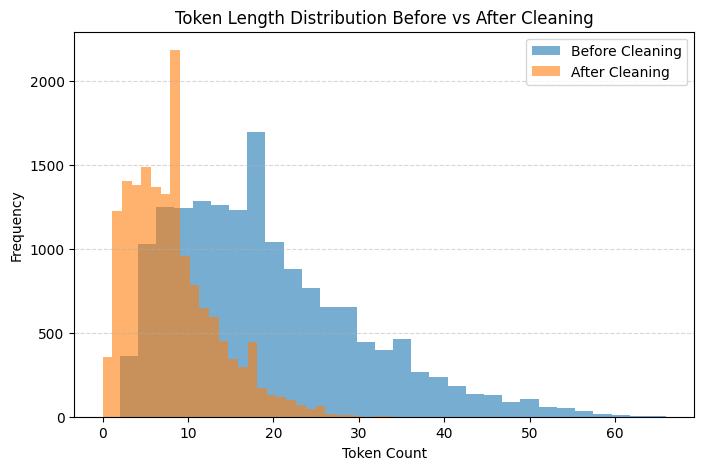

In [ ]:
def token_length_distribution(df, title=''):
  raw_token_counts = df['text'].str.split().apply(len)
  clean_token_counts = df['tokenized'].apply(len)

  plt.figure(figsize=(8,5))
  plt.hist(raw_token_counts, bins=30, alpha=0.6, label='Before Cleaning')
  plt.hist(clean_token_counts, bins=30, alpha=0.6, label='After Cleaning')

  plt.xlabel('Token Count')
  plt.ylabel('Frequency')
  plt.title(title + 'Token Length Distribution Before vs After Cleaning')
  plt.legend()
  plt.grid(axis='y', linestyle='--', alpha=0.5)

  plt.savefig(title + 'Token Length Distribution.jpg')
  files.download(title + 'Token Length Distribution.jpg')
  plt.show()

token_length_distribution(df)

### Set-Up Input and Clean Data

In [ ]:
def clean_data(filename):
    if filename.conatains('.csv'):
        df = load_data(filename)
        emotion_distribution(df)
        df['text'] = df['text'].apply(remove_punct)
        df['text'] = df['text'].apply(remove_stopwords)
        df['text'] = df['text'].apply(tokenize)
        return df
    else:
        print('Invalid File Type. Refer to convert_txt_to_csv, if applicable.')

# Transformer Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sentiment_transformer import SentimentTransformer, create_padding_mask
from collections import Counter
import numpy as np

In [ ]:
class LayerNorm(nn.Module):
    """ LayerNorm but with an optional bias. PyTorch doesn't support simply bias=False """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

In [ ]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [ ]:
class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

In [ ]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y